In [4]:
!nvidia-smi

Sun Mar 29 23:33:47 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# CNN on MNIST with HN_Adam
This notebook trains a deep CNN on MNIST using a 40,000/10,000/10,000 split for train/validation/test with normalized float32 inputs in [0, 1].

In [6]:
"""PyTorch implementation of HN_Adam (Algorithm 2)."""

from __future__ import annotations
from typing import Callable, Iterable, Optional
from torch import Tensor
from torch.optim import Optimizer


class HNAdam(Optimizer):
    """Hybrid and adaptive norm Adam optimizer (HN_Adam)."""

    def __init__(
        self,
        params: Iterable[Tensor],
        lr: float = 1e-3,
        betas: tuple[float, float] = (0.9, 0.999),
        eps: float = 1e-8,
        lambda_t0: Optional[float] = None,
    ) -> None:
        if params is None:
            raise ValueError("params cannot be None.")
        if lr <= 0.0:
            raise ValueError(f"Invalid learning rate: {lr}")
        if eps < 0.0:
            raise ValueError(f"Invalid epsilon value: {eps}")
        if len(betas) != 2:
            raise ValueError("betas must be a tuple of two floats")

        beta1, beta2 = betas
        if not 0.0 <= beta1 < 1.0:
            raise ValueError(f"Invalid beta1 value: {beta1}")
        if not 0.0 <= beta2 < 1.0:
            raise ValueError(f"Invalid beta2 value: {beta2}")

        # Lambda_t0 is randomly chosen in the range [2, 4].
        if lambda_t0 is None:
            lambda_t0 = random.uniform(2.0, 4.0)
        if not 2.0 <= lambda_t0 <= 4.0:
            raise ValueError(f"lambda_t0 must be in [2, 4], got {lambda_t0}")

        defaults = {
            "lr": lr,
            "betas": (beta1, beta2),
            "eps": eps,
            "lambda_t0": lambda_t0,
            "amsgrad": False,
        }
        super().__init__(params, defaults)

        if len(self.param_groups) == 0:
            raise ValueError("optimizer got an empty parameter list")

    @torch.no_grad()
    def step(self, closure: Optional[Callable[[], Tensor]] = None) -> Optional[Tensor]:
        loss: Optional[Tensor] = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        # Step 3: For all t = 1, ..., T do
        for group in self.param_groups:
            lr: float = group["lr"]
            beta1, beta2 = group["betas"]
            eps: float = group["eps"]
            lambda_t0: float = group["lambda_t0"]

            for param in group["params"]:
                if param.grad is None:
                    continue

                grad = param.grad
                if grad.is_sparse:
                    raise RuntimeError("HNAdam does not support sparse gradients")

                state = self.state[param]

                # Initialize: m0 = 0, v0 = 0, amsgrad = False, vhat(0) = 0
                if len(state) == 0:
                    state["step"] = 0
                    state["m"] = torch.zeros_like(param, memory_format=torch.preserve_format)
                    state["v"] = torch.zeros_like(param, memory_format=torch.preserve_format)
                    state["vhat"] = torch.zeros_like(param, memory_format=torch.preserve_format)

                m_prev: Tensor = state["m"]
                v_prev: Tensor = state["v"]
                vhat_prev: Tensor = state["vhat"]

                state["step"] += 1

                # Step 5: g_t <- gradient at the current parameters.
                g_t = grad

                # Step 6: m_t <- beta1 * m_{t-1} + (1 - beta1) * g_t.
                m_t = beta1 * m_prev + (1.0 - beta1) * g_t

                # Step 7: m_max <- Max(m_{t-1}, |g_t|) using Euclidean norms.
                g_abs = g_t.abs()
                m_prev_norm = torch.linalg.vector_norm(m_prev)
                g_abs_norm = torch.linalg.vector_norm(g_abs)
                m_max = torch.maximum(m_prev_norm, g_abs_norm)

                # Step 8: Lambda(t) <- Lambda_t0 - (m_{t-1} / m_max).
                # If m_max == 0, set ratio = 0 to avoid division by zero.
                if m_max.item() == 0.0:
                    ratio = torch.zeros((), dtype=param.dtype, device=param.device)
                else:
                    ratio = m_prev_norm / m_max
                lambda_t = torch.as_tensor(lambda_t0, dtype=param.dtype, device=param.device) - ratio

                # Step 9: v_t <- beta2 * v_{t-1} + (1 - beta2) * (|g_t|)^Lambda(t).
                v_t = beta2 * v_prev + (1.0 - beta2) * g_abs.pow(lambda_t)

                # Step 10: If Lambda(t) < 2 then switch to AMSGrad path.
                if bool((lambda_t < 2.0).item()):
                    # Step 11: amsgrad = True
                    group["amsgrad"] = True

                    # Step 12: vhat_t <- Max(vhat_{t-1}, |v_t|).
                    vhat_t = torch.maximum(vhat_prev, v_t.abs())
                    state["vhat"] = vhat_t

                    # Step 13: theta_t <- theta_{t-1} - eta * m_t / (vhat_t^(1/Lambda(t)) + eps).
                    denom = vhat_t.pow(1.0 / lambda_t) + eps
                else:
                    # Step 15: amsgrad = False
                    group["amsgrad"] = False

                    # Step 16: theta_t <- theta_{t-1} - eta * m_t / (v_t^(1/Lambda(t)) + eps).
                    denom = v_t.pow(1.0 / lambda_t) + eps

                param.addcdiv_(m_t, denom, value=-lr)

                state["m"] = m_t
                state["v"] = v_t

        # Step 18: return final parameters is implicit after repeated updates.
        return loss

In [7]:
transform = transforms.ToTensor()

full_train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_indices = list(range(0, 40000))
val_indices = list(range(40000, 50000))

train_dataset = Subset(full_train_dataset, train_indices)
val_dataset = Subset(full_train_dataset, val_indices)

BATCH_SIZE = 128
num_workers = 2 if torch.cuda.is_available() else 0
pin_memory = torch.cuda.is_available()

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=num_workers, pin_memory=pin_memory)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=num_workers, pin_memory=pin_memory)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=num_workers, pin_memory=pin_memory)

sample_images, _ = full_train_dataset[0]
print(f"Train size: {len(train_dataset)}")
print(f"Validation size: {len(val_dataset)}")
print(f"Test size: {len(test_dataset)}")
print(f"Image dtype: {sample_images.dtype}, min: {sample_images.min().item():.3f}, max: {sample_images.max().item():.3f}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 484kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.51MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.78MB/s]

Train size: 40000
Validation size: 10000
Test size: 10000
Image dtype: torch.float32, min: 0.000, max: 1.000


In [8]:
class DeepCNNMNIST(nn.Module):
    def __init__(self) -> None:
        super().__init__()

        self.block1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3),
            nn.Conv2d(32, 32, kernel_size=3),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.ReLU(inplace=True),
        )

        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3),
            nn.Conv2d(64, 64, kernel_size=3),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.ReLU(inplace=True),
        )

        self.flatten = nn.Flatten()

        self.classifier = nn.Sequential(
            nn.Linear(64 * 4 * 4, 512),
            nn.ReLU(inplace=True),
            nn.Linear(512, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, 32),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.1),
            nn.Linear(32, 10),
        )

        self.softmax = nn.Softmax(dim=1)

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        x = self.block1(x)
        x = self.block2(x)
        x = self.flatten(x)
        logits = self.classifier(x)
        probs = self.softmax(logits)
        return logits, probs


model = DeepCNNMNIST().to(device)
print(model)

with torch.no_grad():
    dummy = torch.zeros(1, 1, 28, 28, device=device)
    features = model.block2(model.block1(dummy))
    print(f"Feature map shape before flatten: {features.shape}")
    print(f"Flattened size: {features.numel()}")

DeepCNNMNIST(
  (block1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1))
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): ReLU(inplace=True)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): ReLU(inplace=True)
  )
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (classifier): Sequential(
    (0): Linear(in_features=1024, out_features=512, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=512, out_features=128, bias=True)
    (3): ReLU(inplace=True)
    (4): Linear(in_features=128, out_features=256, bias=True)
    (5): ReLU(inplace=True)
    (6): Linear(in_features=256, out_features=32, bias=True)
    (7): ReLU(inplace=True)
    (8): Dropout(p=0.1, inplace=False

In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = HNAdam(model.parameters(), lr=1e-3, betas=(0.9, 0.99), eps=1e-8)


def run_epoch(model, dataloader, criterion, optimizer=None):
    is_train = optimizer is not None
    if is_train:
        model.train()
    else:
        model.eval()

    running_loss = 0.0
    running_correct = 0
    total_samples = 0

    for images, labels in dataloader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_train):
            logits, probs = model(images)
            loss = criterion(logits, labels)
            if is_train:
                loss.backward()
                optimizer.step()

        preds = probs.argmax(dim=1)
        running_loss += loss.item() * labels.size(0)
        running_correct += (preds == labels).sum().item()
        total_samples += labels.size(0)

    avg_loss = running_loss / total_samples
    avg_acc = running_correct / total_samples
    return avg_loss, avg_acc

In [10]:
EPOCHS = 15
history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
}

start_time = time.perf_counter()

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer=optimizer)
    val_loss, val_acc = run_epoch(model, val_loader, criterion, optimizer=None)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
    )

training_time_sec = time.perf_counter() - start_time
print(f"\nTraining completed in {training_time_sec:.2f} seconds")

Epoch 01/15 | Train Loss: 0.3881, Train Acc: 0.8736 | Val Loss: 0.2530, Val Acc: 0.9262
Epoch 02/15 | Train Loss: 0.0953, Train Acc: 0.9737 | Val Loss: 0.1460, Val Acc: 0.9606
Epoch 03/15 | Train Loss: 0.0756, Train Acc: 0.9789 | Val Loss: 0.0709, Val Acc: 0.9810
Epoch 04/15 | Train Loss: 0.0614, Train Acc: 0.9827 | Val Loss: 0.0788, Val Acc: 0.9776
Epoch 05/15 | Train Loss: 0.0597, Train Acc: 0.9833 | Val Loss: 0.1284, Val Acc: 0.9675
Epoch 06/15 | Train Loss: 0.0512, Train Acc: 0.9852 | Val Loss: 0.0598, Val Acc: 0.9842
Epoch 07/15 | Train Loss: 0.0428, Train Acc: 0.9884 | Val Loss: 0.0705, Val Acc: 0.9854
Epoch 08/15 | Train Loss: 0.0346, Train Acc: 0.9905 | Val Loss: 0.0689, Val Acc: 0.9838
Epoch 09/15 | Train Loss: 0.0324, Train Acc: 0.9911 | Val Loss: 0.0782, Val Acc: 0.9800
Epoch 10/15 | Train Loss: 0.0341, Train Acc: 0.9909 | Val Loss: 0.0601, Val Acc: 0.9874
Epoch 11/15 | Train Loss: 0.0335, Train Acc: 0.9913 | Val Loss: 0.0565, Val Acc: 0.9877
Epoch 12/15 | Train Loss: 0.0292

In [11]:
test_loss, test_acc = run_epoch(model, test_loader, criterion, optimizer=None)
min_train_loss = float(np.min(history["train_loss"]))

print(f"Minimum training loss: {min_train_loss:.6f}")
print(f"Test loss: {test_loss:.6f}")
print(f"Test accuracy: {test_acc:.4f}")

Minimum training loss: 0.021053
Test loss: 0.054129
Test accuracy: 0.9889


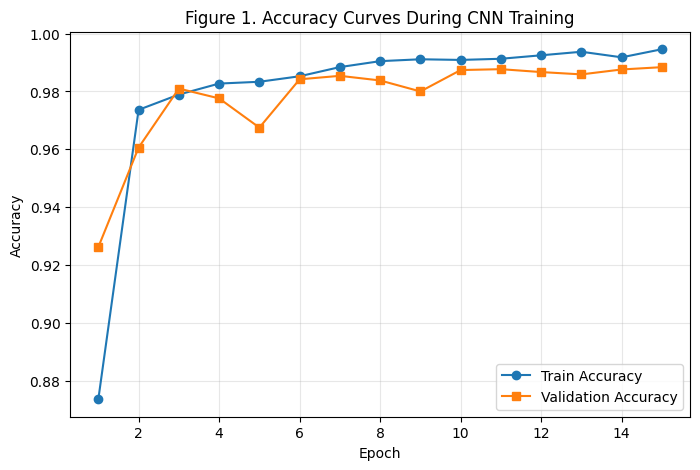

In [12]:
epochs_axis = np.arange(1, EPOCHS + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_axis, history["train_acc"], marker="o", label="Train Accuracy")
plt.plot(epochs_axis, history["val_acc"], marker="s", label="Validation Accuracy")
plt.title("Figure 1. Accuracy Curves During CNN Training")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

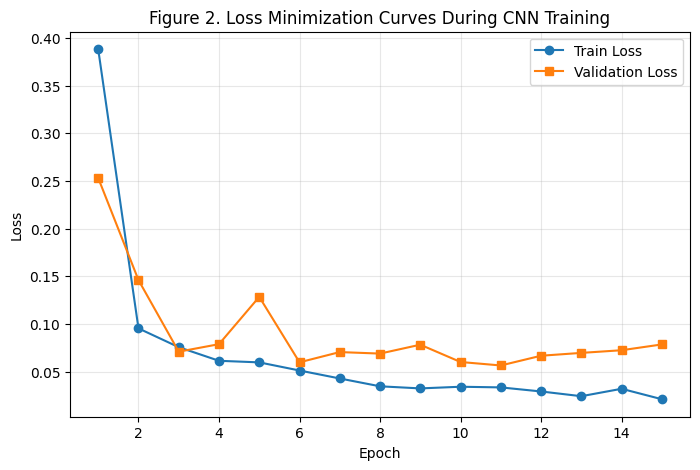

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(epochs_axis, history["train_loss"], marker="o", label="Train Loss")
plt.plot(epochs_axis, history["val_loss"], marker="s", label="Validation Loss")
plt.title("Figure 2. Loss Minimization Curves During CNN Training")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [14]:
table1 = pd.DataFrame(
    [
        ["Minimum Training Loss", f"{min_train_loss:.6f}"],
        ["Testing Accuracy", f"{test_acc:.4f}"],
        ["Training Time (seconds)", f"{training_time_sec:.2f}"],
    ],
    columns=["Metric", "Value"],
)

print("Table 1. CNN Training Summary")
table1

Table 1. CNN Training Summary


,Metric,Value
0,Minimum Training Loss,0.021053
1,Testing Accuracy,0.9889
2,Training Time (seconds),132.27
